In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

In [26]:
df = pd.read_csv('../Dataset/Processed/Merged_Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.tail()

,Date,Close,High,Low,Open,Volume,Company,DE10YT_Yield,EURUSD_Close,EURUSD_Volume,...,OVX_Close,TTF_Gas_Close,VIX_Close,Gold_Close,EBITDA,Net_Income,ROA,Total_Assets,Total_Debt,Cash
615926,2025-12-19,7.58,7.61,7.54,7.57,53.8,ZIGNAGO VETRO,2.8925,1.1708,40683.0,...,33.62,28.20,14.91,3703.98,NaN,NaN,NaN,NaN,NaN,NaN
615927,2025-12-22,7.63,7.70,7.48,7.57,91.6,ZIGNAGO VETRO,2.9044,1.1760,48571.0,...,33.03,27.77,14.08,3777.43,NaN,NaN,NaN,NaN,NaN,NaN
615928,2025-12-23,7.67,7.75,7.61,7.71,50.4,ZIGNAGO VETRO,2.8647,1.1794,55315.0,...,33.02,27.78,14.00,3800.40,NaN,NaN,NaN,NaN,NaN,NaN
615929,2025-12-29,7.79,7.80,7.63,7.63,78.6,ZIGNAGO VETRO,2.8257,1.1772,50852.0,...,32.16,28.69,14.20,3679.45,NaN,NaN,NaN,NaN,NaN,NaN
615930,2025-12-30,7.77,7.84,7.72,7.82,42.7,ZIGNAGO VETRO,2.8533,1.1746,44821.0,...,30.76,27.80,14.33,3691.29,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
num_companies = df['Company'].nunique()
print(f"Number of companies in the dataset: {num_companies}")

oldest_date = df['Date'].min()
print(f"Oldest date in the dataset: {oldest_date}")

Number of companies in the dataset: 186
Oldest date in the dataset: 2009-09-18 00:00:00


In [28]:
features = [
    'Close', 'Volume', 
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 
    'Euribor_3M', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 
    'IT10YT_Yield', 'IT_Inflation', 'IT_GDP', 'IT_Unemployment', 
    'Brent_Close', 'Brent_Volume', 'OVX_Close', 
    'TTF_Gas_Close', 'VIX_Close', 'Gold_Close'
]

targets = ['EBITDA', 'ROA', 'Net_Income']

# Feature Selection & Target Engineering Pipeline
This section of the study aims to identify the most predictive features (market data and macroeconomic indicators) for forecasting corporate fundamental targets (EBITDA, ROA, Net Income). Because the dataset contains sequential financial data, 90-day lookback windows prior to each financial report release are extracted, calculating the **mean** (Level/Trend) and **standard deviation** (Volatility/Shock)for each feature.

To ensure robust and unbiased feature selection, three distinct mathematical frameworks are employed:

**1. Mutual Information**

Mutual Information (MI) is a non-parametric metric that measures the reduction in uncertainty about the target variable given the knowledge of a specific feature. Unlike traditional Pearson correlation, MI is completely model-agnostic and can capture complex, non-linear relationships between macroeconomic shocks and corporate fundamentals.

**2. Random Forest & Gini Importance**

Random Forest is an ensemble learning method and the feature importance is calculated using the Gini Importance (Mean Decrease in Impurity) metric. 
It calculates how much each feature contributes to reducing the variance (in regression) or impurity (in classification) across all the decision trees in the forest. It provides an excellent measure of the absolute predictive power of a variable.

**3. SHAP Values**

While Random Forest shows how much a feature matters, SHAP (SHapley Additive exPlanations) explains how it matters: it values break down the prediction to show the directional impact of each feature. A SHAP summary plot allows us to visually understand whether a high value of a specific feature pushes the model's prediction higher or lower, providing crucial economic interpretability to our black-box models. Red dots indicate that a high value of the feature increases the probability of an upward trend, while blue dots indicate that a high value decreases it. If the dots are on the right side of the plot, it means that the feature pushes the prediction towards an upward trend; if they are on the left, it means that the feature pushes the prediction towards a downward trend.

## Part 1: Absolute Target Analysis - Regression

In this first analytical phase, the algorithms are tasked with predicting the absolute values of the financial targets. 

This approach serves as a baseline to test the models' behavior on raw, unscaled accounting data. We treat this as a continuous Regression problem using `RandomForestRegressor` and `mutual_info_regression`.


                                EBITDA                                
Total valid 90-day windows extracted: 4446


/Users/davide/UniPD/Tesi/xLSTM/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/davide/UniPD/Tesi/xLSTM/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Model comparison (test metrics):
Raw Target RF  -> R2: 0.9447 | MAE: 117292.9341 | RMSE: 653457.5259 | Avg % Diff: 133.56% | WAPE: 15.02% | sMAPE: 30.86%
Signed-Log RF  -> R2: 0.9110 | MAE: 178690.9564 | RMSE: 828829.2055 | Avg % Diff: 71.32% | WAPE: 22.88% | sMAPE: 44.84%

Selected model for EBITDA: Raw-Target RF (selected)
Best RF Params for EBITDA: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 109126.0011 | RMSE: 680400.0985 | R2: 0.9349 | Avg % Diff: 116.05% | Median % Diff: 5.07% | WAPE: 14.01% | sMAPE: 24.69%
Test  -> MAE: 117292.9341 | RMSE: 653457.5259 | R2: 0.9447 | Avg % Diff: 133.56% | Median % Diff: 7.93% | WAPE: 15.02% | sMAPE: 30.86%

Sample of predicted vs actual values for EBITDA:
   Actual    Predicted   Abs_Error  Pct_Diff_%
 107000.0  126164.4275  19164.4275   17.910680
  56361.0   61558.1885   5197.1885    9.221250
  28499.0   28116.2950    

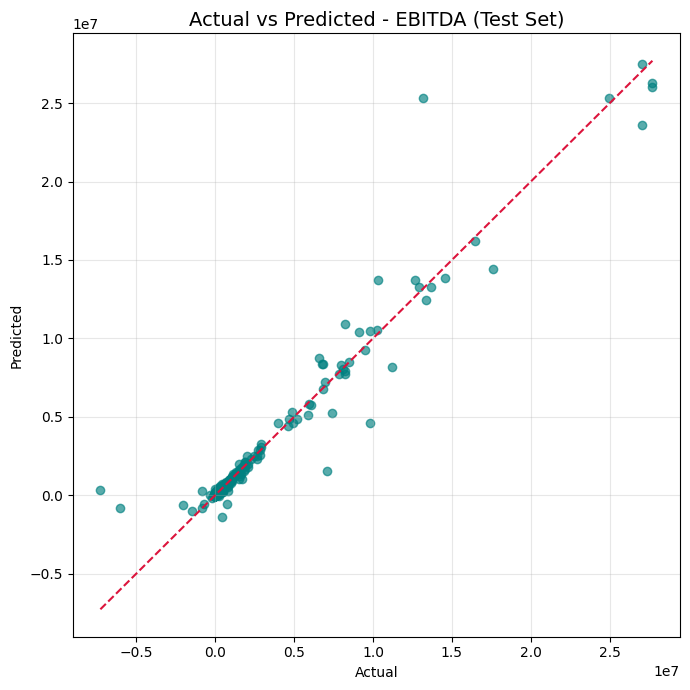

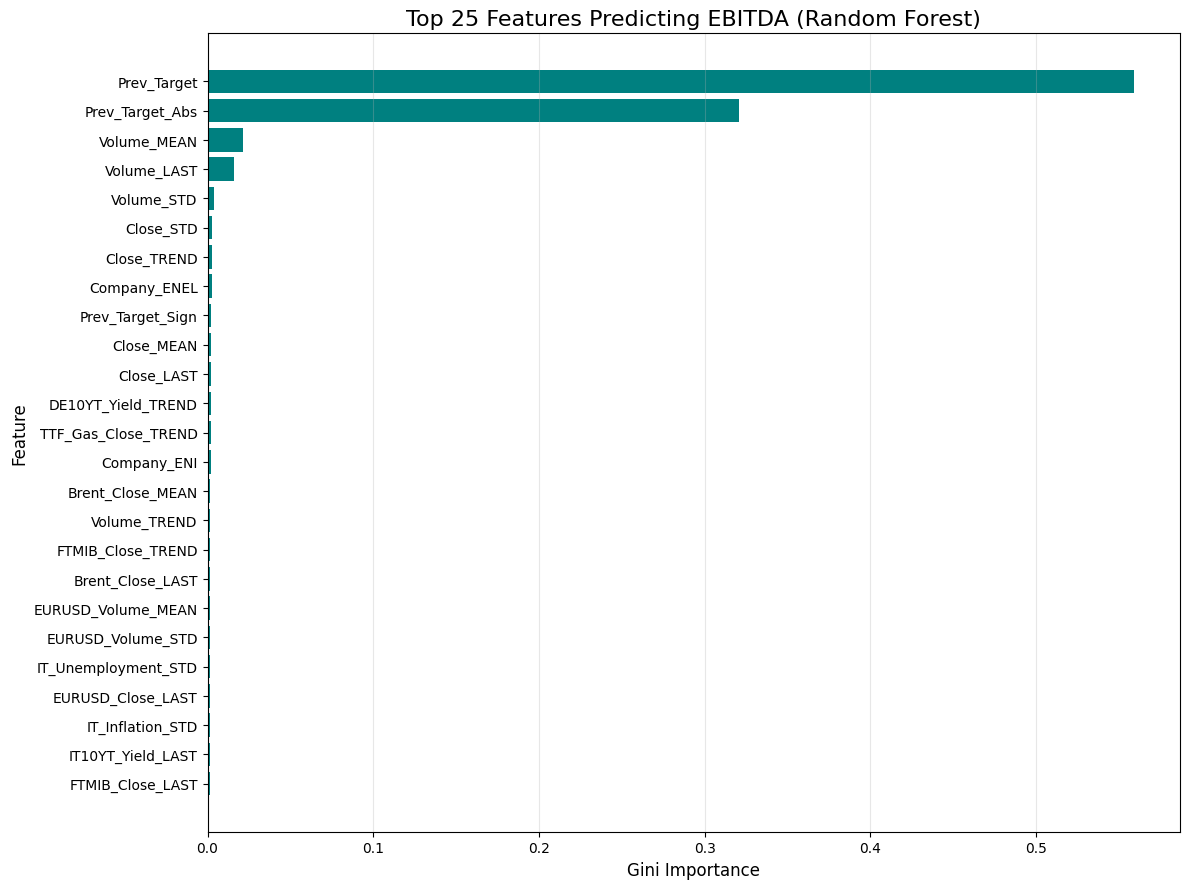


                                 ROA                                  
Total valid 90-day windows extracted: 4500

Model comparison (test metrics):
Raw Target RF  -> R2: -2.2222 | MAE: 0.0353 | RMSE: 0.2402 | Avg % Diff: 150.93% | WAPE: 63.66% | sMAPE: 46.73%
Signed-Log RF  -> R2: -0.2880 | MAE: 0.0252 | RMSE: 0.1519 | Avg % Diff: 137.04% | WAPE: 45.57% | sMAPE: 46.02%

Selected model for ROA: Signed-Log RF (selected)
Best RF Params for ROA: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 0.0401 | RMSE: 0.8021 | R2: 0.1237 | Avg % Diff: 121.40% | Median % Diff: 7.76% | WAPE: 45.45% | sMAPE: 33.18%
Test  -> MAE: 0.0252 | RMSE: 0.1519 | R2: -0.2880 | Avg % Diff: 137.04% | Median % Diff: 12.55% | WAPE: 45.57% | sMAPE: 46.02%

Sample of predicted vs actual values for ROA:
   Actual  Predicted  Abs_Error  Pct_Diff_%
-0.008322   0.008271   0.016593  199.388995
-0.05412

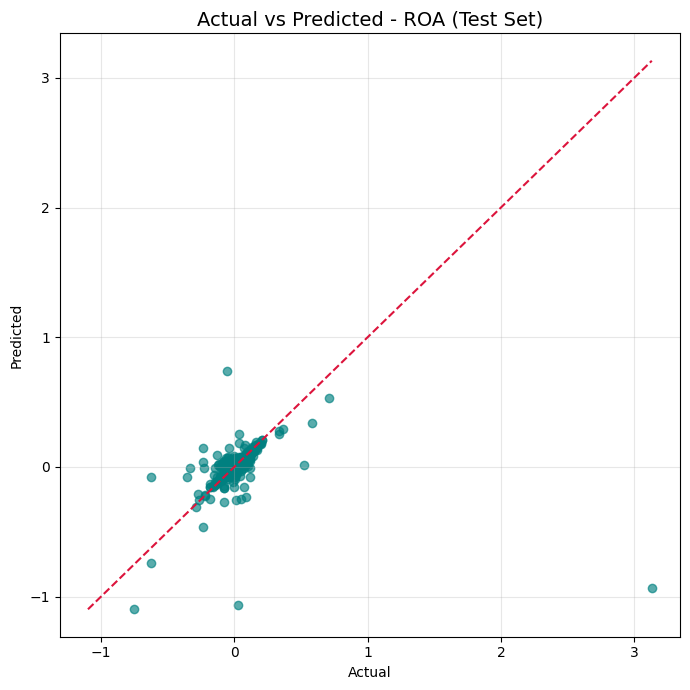

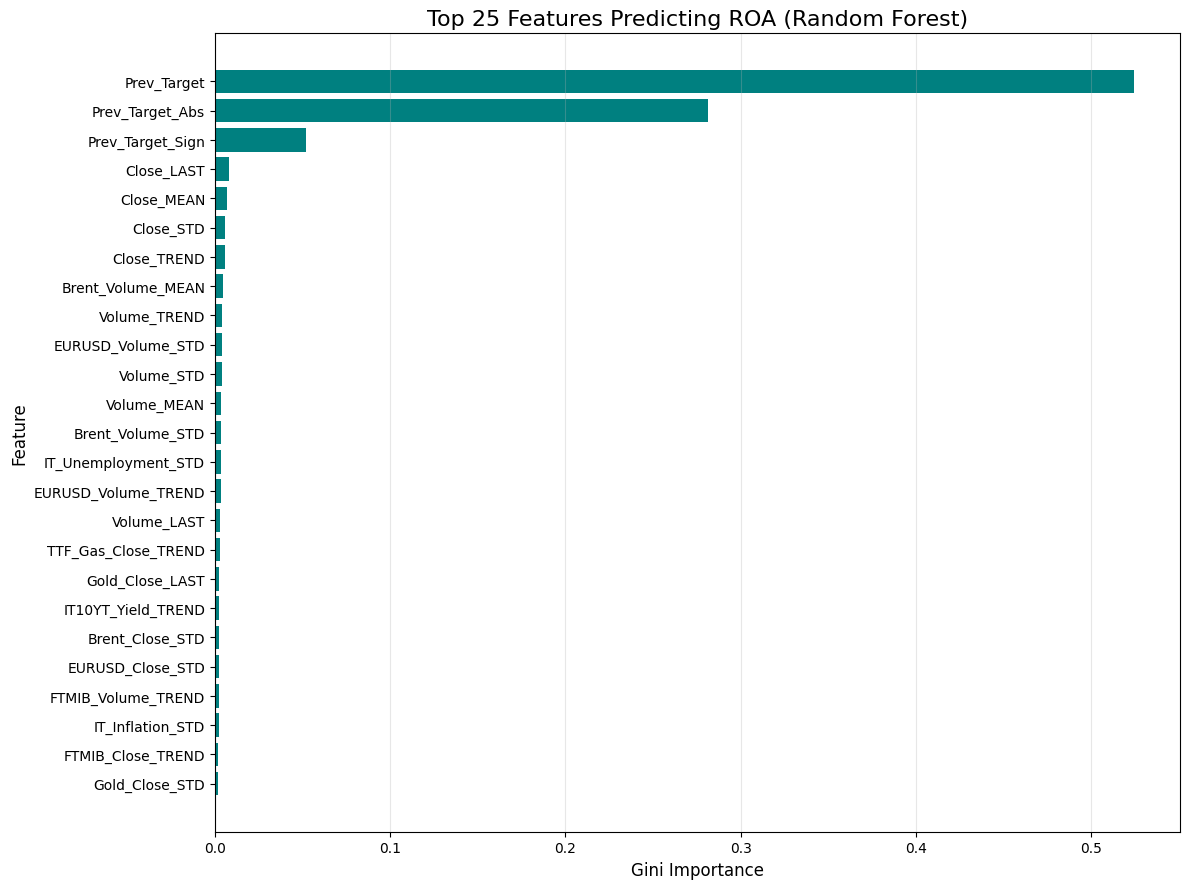


                              Net_Income                              
Total valid 90-day windows extracted: 4503

Model comparison (test metrics):
Raw Target RF  -> R2: 0.8488 | MAE: 99500.9342 | RMSE: 432427.5997 | Avg % Diff: 309.89% | WAPE: 31.04% | sMAPE: 47.19%
Signed-Log RF  -> R2: 0.7187 | MAE: 133945.6634 | RMSE: 589722.6817 | Avg % Diff: 59.33% | WAPE: 41.79% | sMAPE: 71.10%

Selected model for Net_Income: Raw-Target RF (selected)
Best RF Params for Net_Income: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 94596.2600 | RMSE: 618133.0127 | R2: 0.7774 | Avg % Diff: 231.84% | Median % Diff: 9.94% | WAPE: 27.69% | sMAPE: 34.88%
Test  -> MAE: 99500.9342 | RMSE: 432427.5997 | R2: 0.8488 | Avg % Diff: 309.89% | Median % Diff: 15.98% | WAPE: 31.04% | sMAPE: 47.19%

Sample of predicted vs actual values for Net_Income:
    Actual     Predicted    Abs_Error  Pct

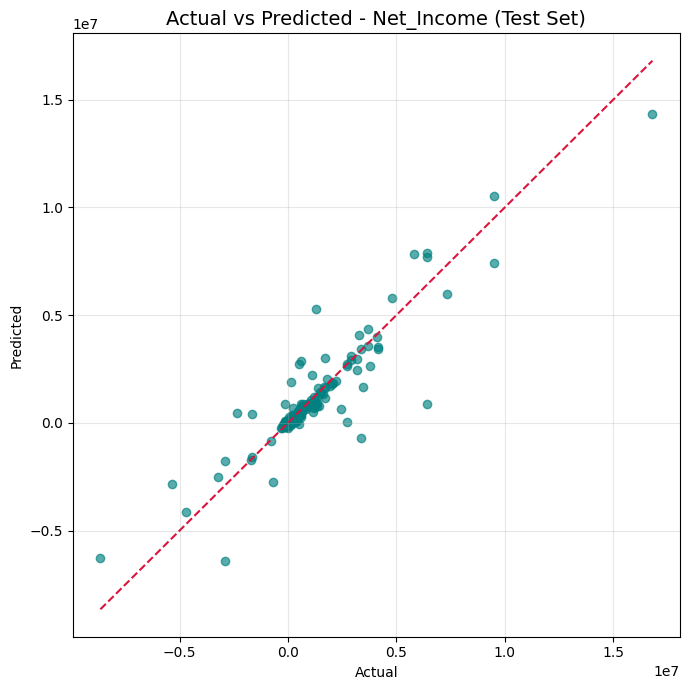

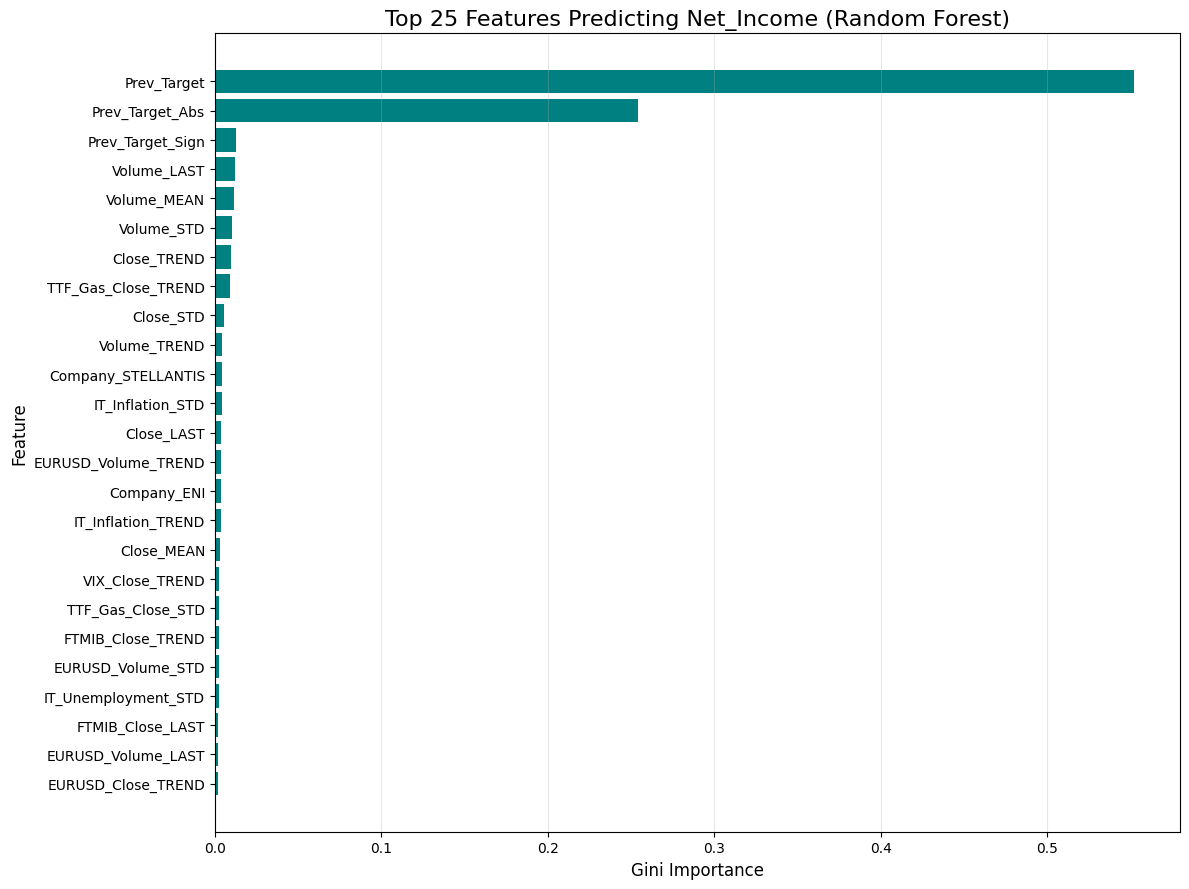


Final Test Performance Summary (selected model per target)
    Target           Selected_Model   Test_R2     Test_RMSE      Test_MAE  AvgPctDiff_%  MedianPctDiff_%    WAPE_%   sMAPE_%
    EBITDA Raw-Target RF (selected)  0.944674 653457.525903 117292.934108    133.561724         7.926882 15.020950 30.859626
       ROA Signed-Log RF (selected) -0.288028      0.151866      0.025245    137.042205        12.554407 45.572540 46.015070
Net_Income Raw-Target RF (selected)  0.848763 432427.599672  99500.934183    309.885877        15.980335 31.043255 47.192190


In [29]:
performance_summary = []

# Speed-up: pre-split by company once instead of filtering the full dataframe for each sample
df_by_company = {company: grp.sort_values('Date') for company, grp in df.groupby('Company')}

for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        # Previous known target is usually the strongest baseline for quarterly fundamentals
        prev_target_values = company_targets[target].shift(1)

        for row_idx, (_, row) in enumerate(company_targets.iterrows()):
            target_date = row['Date']
            target_value = row[target]
            prev_target = prev_target_values.iloc[row_idx]

            start_date = target_date - pd.Timedelta(days=90)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            if len(window) <= 40:
                continue

            window_stats = {'Company': company}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    window_stats[f"{feat}_MEAN"] = 0.0
                    window_stats[f"{feat}_STD"] = 0.0
                    window_stats[f"{feat}_LAST"] = 0.0
                    window_stats[f"{feat}_TREND"] = 0.0
                else:
                    values = series.values.astype(float)
                    window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                    window_stats[f"{feat}_STD"] = float(np.std(values))
                    window_stats[f"{feat}_LAST"] = float(values[-1])

                    if len(values) > 1:
                        x_axis = np.arange(len(values), dtype=float)
                        slope = np.polyfit(x_axis, values, deg=1)[0]
                    else:
                        slope = 0.0
                    window_stats[f"{feat}_TREND"] = float(slope)

            if pd.notna(prev_target):
                window_stats['Prev_Target'] = float(prev_target)
                window_stats['Prev_Target_Abs'] = float(abs(prev_target))
                window_stats['Prev_Target_Sign'] = float(np.sign(prev_target))
            else:
                window_stats['Prev_Target'] = 0.0
                window_stats['Prev_Target_Abs'] = 0.0
                window_stats['Prev_Target_Sign'] = 0.0

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 90-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    # One-hot encode company to model firm-specific structural scale differences
    X_df = pd.get_dummies(X_df, columns=['Company'], drop_first=True, dtype=float).fillna(0.0)

    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.2, random_state=42
    )

    param_distributions = {
        'n_estimators': [400, 700, 1000, 1300],
        'max_depth': [None, 10, 16, 24, 32],
        'min_samples_split': [2, 4, 8, 12],
        'min_samples_leaf': [1, 2, 4, 6],
        'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
        'bootstrap': [True],
        'criterion': ['squared_error', 'absolute_error']
    }

    def fit_rf(X_train_local, y_train_local):
        base_rf = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=False)
        rf_search = RandomizedSearchCV(
            estimator=base_rf,
            param_distributions=param_distributions,
            n_iter=35,
            cv=4,
            scoring='neg_mean_absolute_error',
            random_state=42,
            n_jobs=-1
        )
        rf_search.fit(X_train_local, y_train_local)
        return rf_search.best_estimator_, rf_search.best_params_

    def signed_log_transform(y):
        return np.sign(y) * np.log1p(np.abs(y))

    def signed_log_inverse(y):
        return np.sign(y) * np.expm1(np.abs(y))

    def regression_metrics(y_true, y_pred):
        eps = 1e-8
        abs_err = np.abs(y_pred - y_true)
        mae = float(mean_absolute_error(y_true, y_pred))
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        r2 = float(r2_score(y_true, y_pred))
        avg_pct_diff = float(np.mean(abs_err / np.maximum(np.abs(y_true), eps)) * 100.0)
        median_pct_diff = float(np.median(abs_err / np.maximum(np.abs(y_true), eps)) * 100.0)
        wape = float(np.sum(abs_err) / np.maximum(np.sum(np.abs(y_true)), eps) * 100.0)
        smape = float(
            np.mean(2.0 * abs_err / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100.0
        )
        return {
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'AvgPctDiff': avg_pct_diff,
            'MedianPctDiff': median_pct_diff,
            'WAPE': wape,
            'sMAPE': smape
        }

    # Model A: raw target
    rf_raw, params_raw = fit_rf(X_train, y_train.values)
    y_train_pred_raw = rf_raw.predict(X_train)
    y_test_pred_raw = rf_raw.predict(X_test)
    train_raw = regression_metrics(y_train.values, y_train_pred_raw)
    test_raw = regression_metrics(y_test.values, y_test_pred_raw)

    # Model B: signed-log target
    y_train_log = signed_log_transform(y_train.values)
    rf_log, params_log = fit_rf(X_train, y_train_log)
    y_train_pred_log = signed_log_inverse(rf_log.predict(X_train))
    y_test_pred_log = signed_log_inverse(rf_log.predict(X_test))
    train_log = regression_metrics(y_train.values, y_train_pred_log)
    test_log = regression_metrics(y_test.values, y_test_pred_log)

    # Select model by weighted absolute percentage error for robustness
    use_log_model = test_log['WAPE'] < test_raw['WAPE']

    if use_log_model:
        rf = rf_log
        model_label = 'Signed-Log RF (selected)'
        y_train_pred = y_train_pred_log
        y_test_pred = y_test_pred_log
        best_params = params_log
        train_metrics = train_log
        test_metrics = test_log
    else:
        rf = rf_raw
        model_label = 'Raw-Target RF (selected)'
        y_train_pred = y_train_pred_raw
        y_test_pred = y_test_pred_raw
        best_params = params_raw
        train_metrics = train_raw
        test_metrics = test_raw

    print("\nModel comparison (test metrics):")
    print(f"Raw Target RF  -> R2: {test_raw['R2']:.4f} | MAE: {test_raw['MAE']:.4f} | RMSE: {test_raw['RMSE']:.4f} | Avg % Diff: {test_raw['AvgPctDiff']:.2f}% | WAPE: {test_raw['WAPE']:.2f}% | sMAPE: {test_raw['sMAPE']:.2f}%")
    print(f"Signed-Log RF  -> R2: {test_log['R2']:.4f} | MAE: {test_log['MAE']:.4f} | RMSE: {test_log['RMSE']:.4f} | Avg % Diff: {test_log['AvgPctDiff']:.2f}% | WAPE: {test_log['WAPE']:.2f}% | sMAPE: {test_log['sMAPE']:.2f}%")

    print(f"\nSelected model for {target}: {model_label}")
    print(f"Best RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Selected_Model': model_label,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    comparison_df = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_test_pred
    })
    comparison_df['Abs_Error'] = np.abs(comparison_df['Actual'] - comparison_df['Predicted'])
    comparison_df['Pct_Diff_%'] = (
        comparison_df['Abs_Error'] / np.maximum(np.abs(comparison_df['Actual']), 1e-8)
    ) * 100.0

    print(f"\nSample of predicted vs actual values for {target}:")
    print(comparison_df.head(12).to_string(index=False))

    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, y_test_pred, alpha=0.65, color='teal')
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='crimson', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {target} (Test Set)', fontsize=14)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()

    rf_save_path = f'../Analysis/Features Importance/Absolute Target/{target}_RF.png'
    plt.savefig(rf_save_path, dpi=300, bbox_inches='tight')
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (selected model per target)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

## Part 2: Momentum and Directional Forecasting

The results from Part 1 reveal a critical structural bias in predicting absolute financial variables, commonly known as the "Size Trap". 
For raw targets like EBITDA and Net Income, the models assigned overwhelming importance to trading volumes (`Volume_MEAN` and `Volume_STD`). Because the dataset contains both Small Cap and Large Cap companies, the algorithm stops analyzing financial performance and instead uses Volume as a proxy for Market Capitalization. It essentially learns a basic heuristic: companies with high trading volumes are massive, therefore their EBITDA will be in the billions.

To build a true predictive model that evaluates economic performance rather than company scale, the target variables are changed using two key transformations:
1. **Quarter-over-Quarter (QoQ) Momentum:** Instead of predicting the absolute level of the fundamentals, we calculate the percentage change compared to the previous quarter. A +5% growth is mathematically identical for a multi-national corporation and a local startup, effectively neutralizing the size bias.
2. **Directional Target (Classification):** the QoQ momentum is further refined into a binary target: **1 (Up)** if the fundamental improved, and **0 (Down)** if it worsened. 

By shifting the architecture from Regression to **Binary Classification**, we force the algorithms to ignore the company's size and focus exclusively on the macroeconomic drivers and market signals that dictate economic expansion or contraction.

In [6]:
directional_targets = []

for target in targets:
    df_valid = df.dropna(subset=[target]).copy()
    
    # Calculate Quarter-over-Quarter percentage change
    qoq_col = f"{target}_QoQ_Pct"
    df_valid[qoq_col] = df_valid.groupby('Company')[target].pct_change(1)
    
    # Define Direction: 1 if UP (QoQ > 0), 0 if DOWN or FLAT
    dir_col = f"{target}_Direction_Up"
    df_valid[dir_col] = np.where(df_valid[qoq_col] > 0, 1, 0)
    
    # If QoQ is NaN (first known value of the company), set Direction to NaN
    df_valid.loc[df_valid[qoq_col].isna(), dir_col] = np.nan
    df.loc[df_valid.index, dir_col] = df_valid[dir_col]
    directional_targets.append(dir_col)


                         EBITDA_Direction_Up                          
Total valid 90-day windows extracted for classification: 4397

Top 10 Features by Mutual Information for EBITDA_Direction_Up:
             Feature  MI_Score
   IT10YT_Yield_MEAN  0.245430
    IT_Inflation_STD  0.242295
      VIX_Close_MEAN  0.242115
  TTF_Gas_Close_MEAN  0.241870
   IT_Inflation_MEAN  0.240075
    FTMIB_Close_MEAN  0.239245
      OVX_Close_MEAN  0.238774
      GVZ_Close_MEAN  0.237266
      Euribor_3M_STD  0.237172
IT_Unemployment_MEAN  0.236975


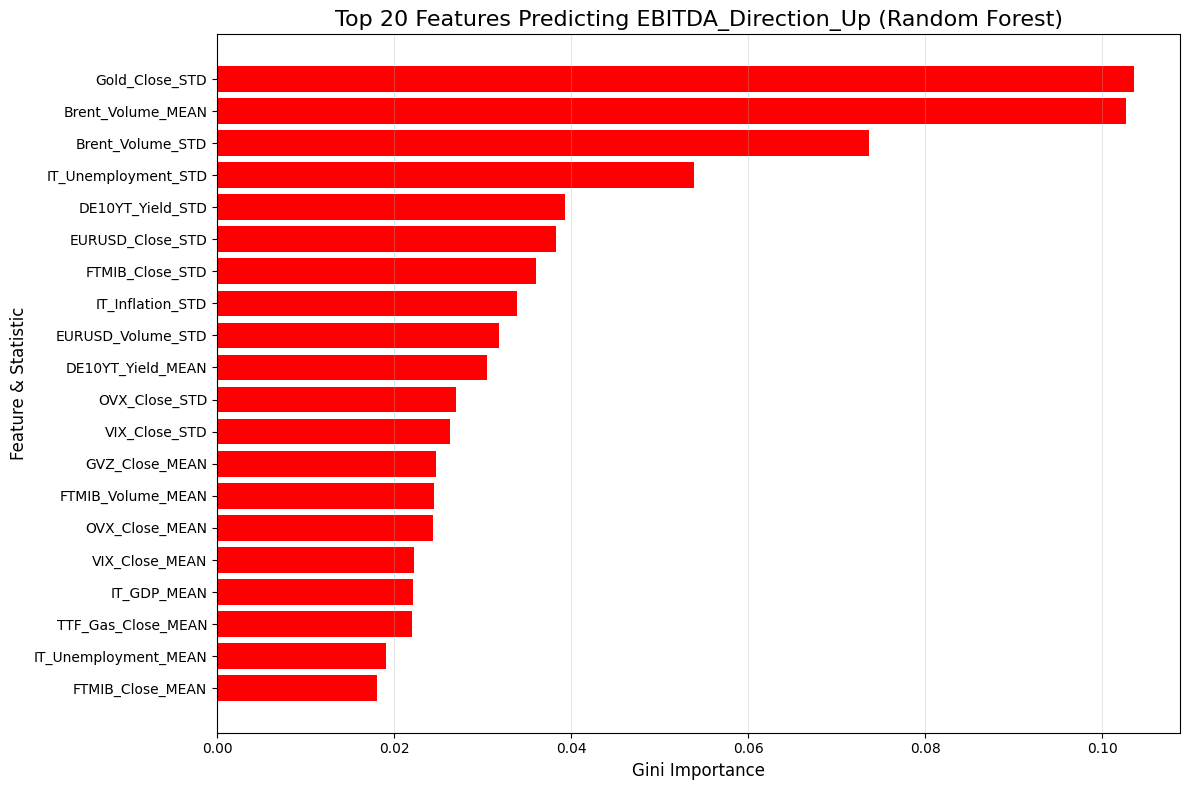

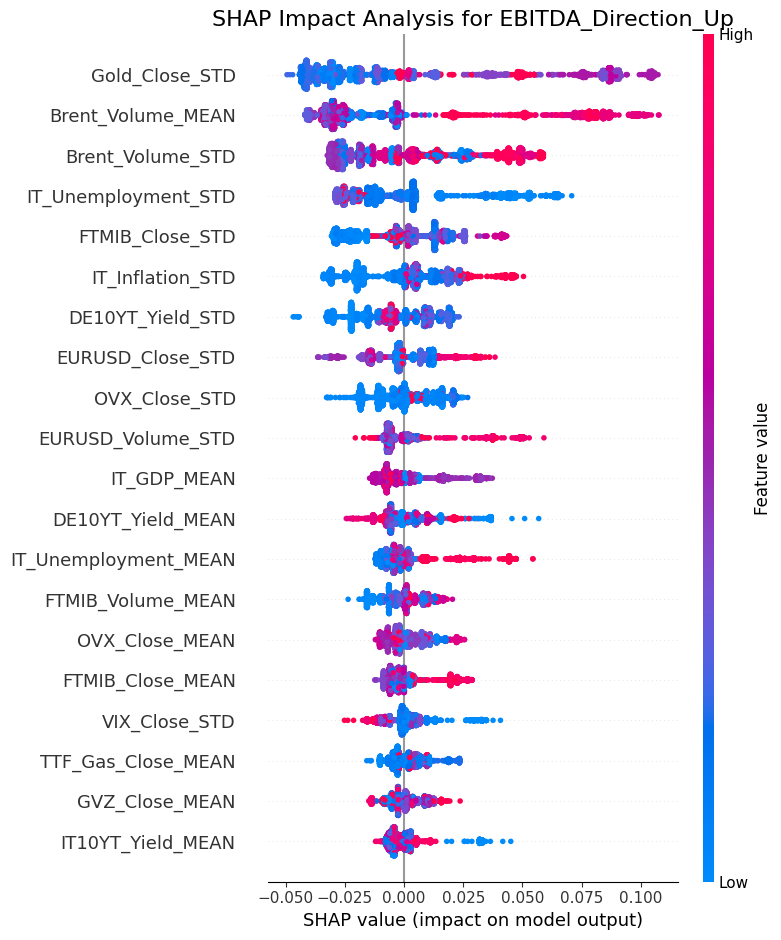


                           ROA_Direction_Up                           
Total valid 90-day windows extracted for classification: 4456

Top 10 Features by Mutual Information for ROA_Direction_Up:
           Feature  MI_Score
   Gold_Close_MEAN  0.165848
  Brent_Close_MEAN  0.164358
 Brent_Volume_MEAN  0.163428
TTF_Gas_Close_MEAN  0.163078
 IT10YT_Yield_MEAN  0.162638
 IT_Inflation_MEAN  0.161528
    OVX_Close_MEAN  0.161441
  FTMIB_Close_MEAN  0.161328
    Euribor_3M_STD  0.160251
     OVX_Close_STD  0.159580


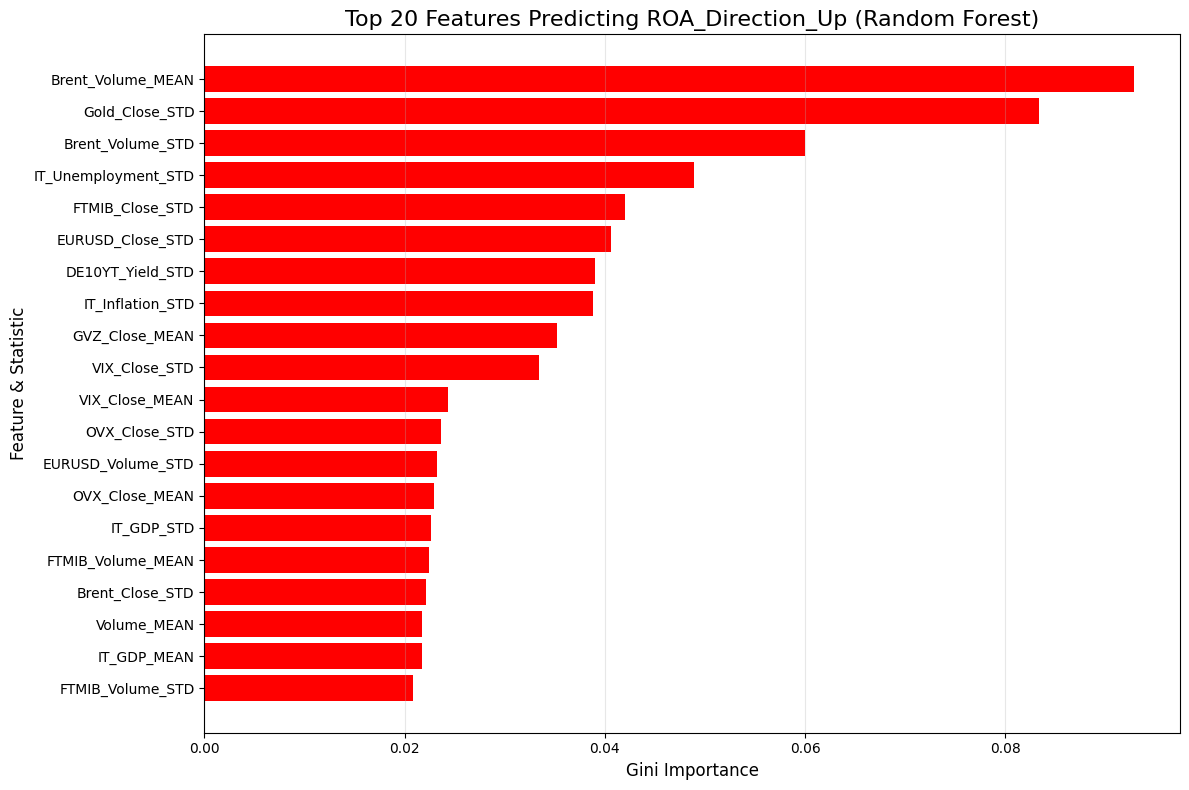

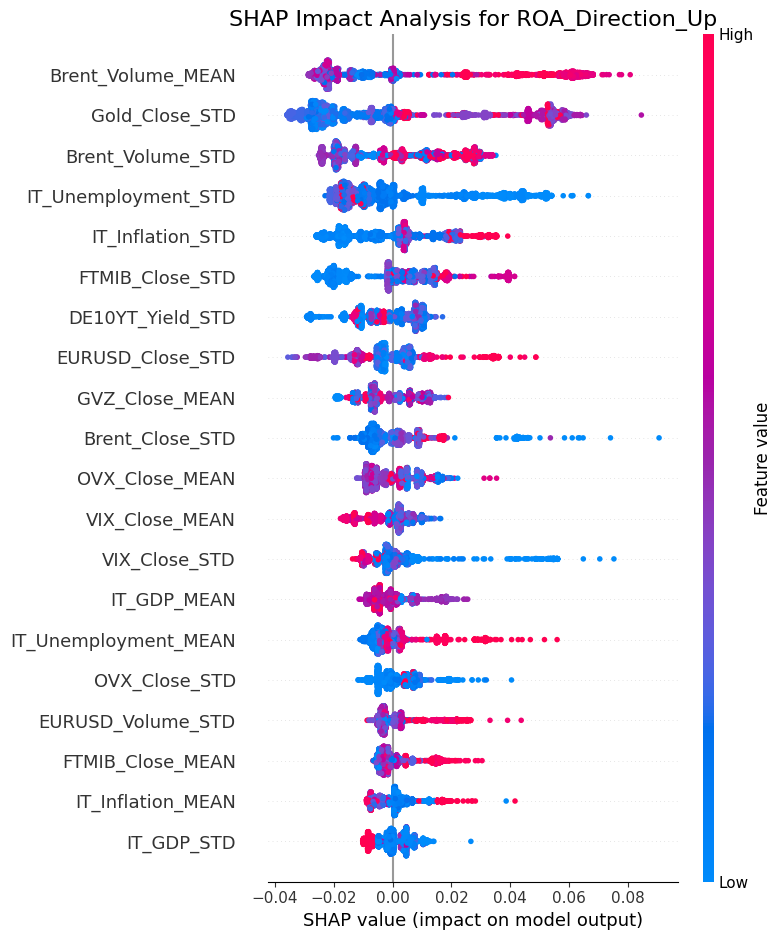


                       Net_Income_Direction_Up                        
Total valid 90-day windows extracted for classification: 4459

Top 10 Features by Mutual Information for Net_Income_Direction_Up:
             Feature  MI_Score
      Euribor_3M_STD  0.190595
IT_Unemployment_MEAN  0.189565
  TTF_Gas_Close_MEAN  0.186457
   IT10YT_Yield_MEAN  0.186289
     Euribor_3M_MEAN  0.186213
      VIX_Close_MEAN  0.186196
   IT_Inflation_MEAN  0.185627
   Brent_Volume_MEAN  0.185488
    DE10YT_Yield_STD  0.185289
   TTF_Gas_Close_STD  0.185271


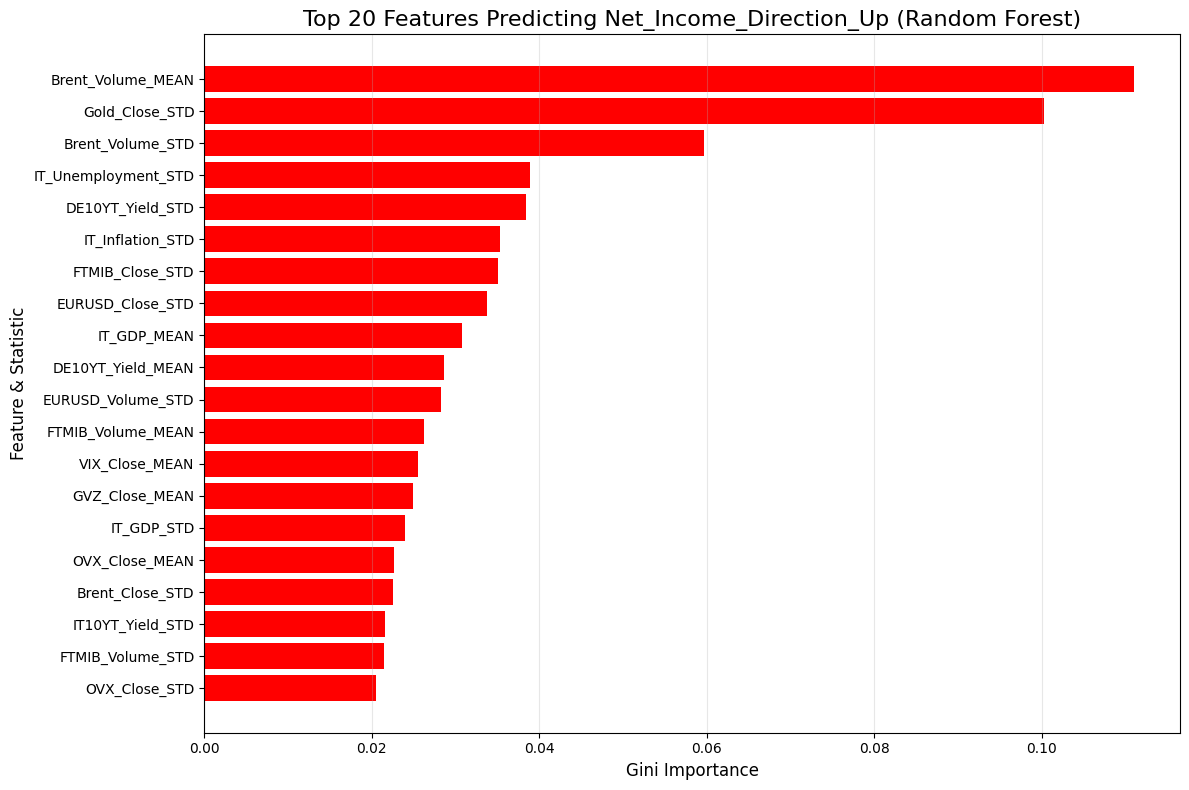

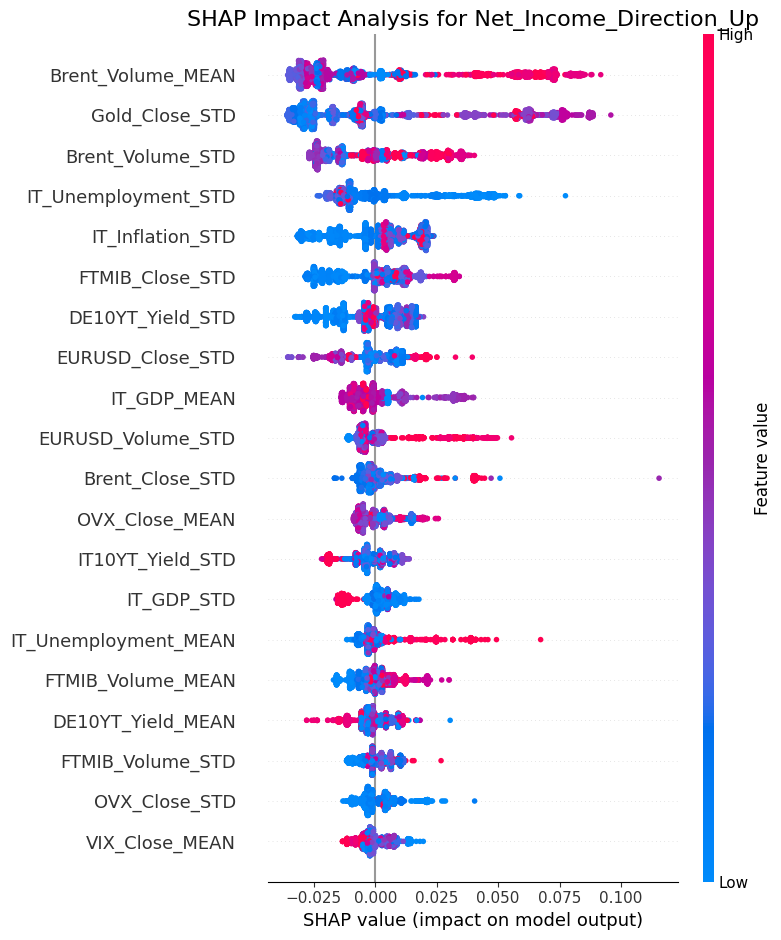

In [7]:
for target in directional_targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []
    target_indices = df[df[target].notna()].index

    for idx in target_indices:
        target_date = df.loc[idx, 'Date']
        company = df.loc[idx, 'Company']
        target_value = df.loc[idx, target]
        
        start_date = target_date - pd.Timedelta(days=90)
        
        window = df[(df['Company'] == company) & 
                    (df['Date'] > start_date) & 
                    (df['Date'] <= target_date)]
        
        if len(window) > 40:
            window_stats = {}
            for feat in features:
                window_stats[f"{feat}_MEAN"] = window[feat].mean()
                window_stats[f"{feat}_STD"] = window[feat].std()
                
            X_aggregated.append(window_stats)
            y_values.append(target_value)

    X_df = pd.DataFrame(X_aggregated).fillna(0)
    y_series = pd.Series(y_values)
    
    print(f"Total valid 90-day windows extracted for classification: {len(X_df)}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)
    
    # Mutual Information
    mi_scores = mutual_info_classif(X_scaled, y_series, random_state=42)
    mi_df = pd.DataFrame({
        'Feature': X_df.columns,
        'MI_Score': mi_scores
    }).sort_values(by='MI_Score', ascending=False)
    
    print(f"\nTop 10 Features by Mutual Information for {target}:")
    print(mi_df.head(10).to_string(index=False))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
    rf.fit(X_scaled, y_series)

    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Plot Classification Random Forest
    top_features = importance_df.head(20).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Importance'], color='red')
    plt.title(f'Top 20 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature & Statistic', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    
    rf_save_path = f'../Analysis/Features Importance/Momentum and Direction/{target}_RF.png'
    plt.savefig(rf_save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Plot SHAP Values for Class 1 (UP)
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    
    # Isolate class 1 (up) to see what pushes the probability of a positive trend
    if isinstance(shap_values, list):
        shap_values_up = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_up = shap_values[:, :, 1]
    else:
        shap_values_up = shap_values
        
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values_up, X_df, plot_type="dot", show=False)
    plt.tight_layout()
    
    shap_save_path = f'../Analysis/Features Importance/Momentum and Direction/{target}_SHAP.png'
    plt.savefig(shap_save_path, dpi=300, bbox_inches='tight')
    plt.show()
